# 05 — Hybrid: prediction + explainability

**Prereqs:** `02` (bundle under `03_ml_layer_hybrid/artifacts/`) and **`04_hybrid_xai_train`** (writes `hybrid_xai/` under the same `artifacts/` tree). Feature lookup for `build_yc_hybrid_vector` uses **`hf_data/.../outputs/`** (latest table) via `yc_hybrid_inference` unless you pass `yc_csv=`.

For each listing you get: **price**, **SHAP** (proxy per cluster XGB / global), **LIME**, **surrogate** rule path, **Apriori** matches, **CBR** neighbours, **what-if** deltas on key features.

Feature names are shown with **human-readable labels** via `feature_labels.py` (SHAP plots, printed SHAP/LIME/surrogate lines, CBR table headers, what-if table).

In [1]:
import importlib
import json
import sys
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import shap
import lime.lime_tabular

warnings_note = __import__("warnings")
warnings_note.filterwarnings("ignore")

_HERE = Path.cwd().resolve()
REPO_ROOT = _HERE if (_HERE / "hf_data").exists() else _HERE.parent
HYBRID_DIR = REPO_ROOT / "03_ml_layer_hybrid"
_XAI_LAYER = REPO_ROOT / "04_xai_layer"
for _p in (HYBRID_DIR, _XAI_LAYER):
    if _p.exists() and str(_p) not in sys.path:
        sys.path.insert(0, str(_p))

import yc_hybrid_inference as yhi
importlib.reload(yhi)
from yc_hybrid_inference import (
    build_yc_hybrid_vector,
    load_bundle,
    predict_price,
    USER_INPUT_KEYS,
)
from feature_labels import feature_label, label_lime_line, label_rule_text, labels_for_columns

HERE = REPO_ROOT
ART = HYBRID_DIR / "artifacts"
OUT_DIR = ART / "hybrid_xai"

bundle = load_bundle()
FEATURE_COLS = bundle["feature_columns"]
FEATURE_LABELS = labels_for_columns(FEATURE_COLS)
shap_payload = joblib.load(OUT_DIR / "shap_explainers.joblib")
per_cluster_exp = shap_payload["per_cluster"]
fallback_ids = set(shap_payload["fallback_cluster_ids"])
explainer_global = shap_payload["global_xgb_explainer"]

surrogate = joblib.load(OUT_DIR / "surrogate_model.joblib")
lime_pack = joblib.load(OUT_DIR / "lime_training_data.joblib")
with open(OUT_DIR / "rules.json") as f:
    rules_json = json.load(f)

cbr_tree = joblib.load(OUT_DIR / "cbr_index.joblib")
cbr_scaler = joblib.load(OUT_DIR / "cbr_scaler.joblib")
cbr_df = pd.read_parquet(OUT_DIR / "cbr_training_data.parquet")
with open(OUT_DIR / "cbr_features.json") as f:
    CBR_FEATURES = json.load(f)

print("Loaded bundle + hybrid_xai artefacts.")

/Users/bhuvesh/Documents/PropertyLens/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


FileNotFoundError: [Errno 2] No such file or directory: '/Users/bhuvesh/Documents/PropertyLens/03_ml_layer_hybrid/artifacts/hybrid_xai/surrogate_model.joblib'

In [ ]:
def hybrid_predict(X):
    return predict_price(np.asarray(X, dtype=float), bundle)


def cluster_id_for_X(X_row_2d):
    idx = [FEATURE_COLS.index(c) for c in bundle["cluster_cols"]]
    Xc = np.asarray(X_row_2d[:, idx], dtype=float)
    lab = bundle["kmeans"].predict(bundle["cluster_scaler"].transform(Xc))
    return int(lab[0])


def shap_for_row(X_row_2d):
    k = cluster_id_for_X(X_row_2d)
    cb = bundle["cluster_bundles"]
    cbk = cb[k] if k in cb else cb[str(k)]
    if cbk.get("fallback") or k in fallback_ids:
        exp = explainer_global
        label = f"global XGB (fallback cluster {k})"
    else:
        exp = per_cluster_exp[k]
        label = f"cluster {k} XGB"
    sv = exp(X_row_2d)
    return sv, label, k


# Example user input (edit)
user_input = {
    "block": "18C",
    "street_name": "CIRCUIT ROAD",
    "town": "GEYLANG",
    "flat_type": "4 ROOM",
    "floor_area_sqm": 93,
    "storey_range": "07 TO 09",
    "lease_commence_date": 2015,
    "sale_month": "2026-04",
}

user_input = {
    "block": "1",
    "street_name": "LORONG LEW LIAN",
    "town": "SERANGOON",
    "flat_type": "3 ROOM",
    "floor_area_sqm": 64,
    "storey_range": "07 TO 09",
    "lease_commence_date": 1978,
    "sale_month": "2026-04",
}

built = build_yc_hybrid_vector(
    user_input["block"],
    user_input["street_name"],
    user_input["town"],
    user_input["flat_type"],
    user_input["floor_area_sqm"],
    user_input["storey_range"],
    user_input["lease_commence_date"],
    user_input["sale_month"],
)
X = built["vector"]
price = float(predict_price(X, bundle)[0])
print(f"Predicted resale price (SGD): {price:,.2f}")
print("Lookup matched:", built["lookup_matched"], "|", built.get("matched_address_key"))
if built.get("imputation_note"):
    print("Note:", built["imputation_note"])

Predicted resale price (SGD): 428,300.37
Lookup matched: True | 1 LOR LEW LIAN


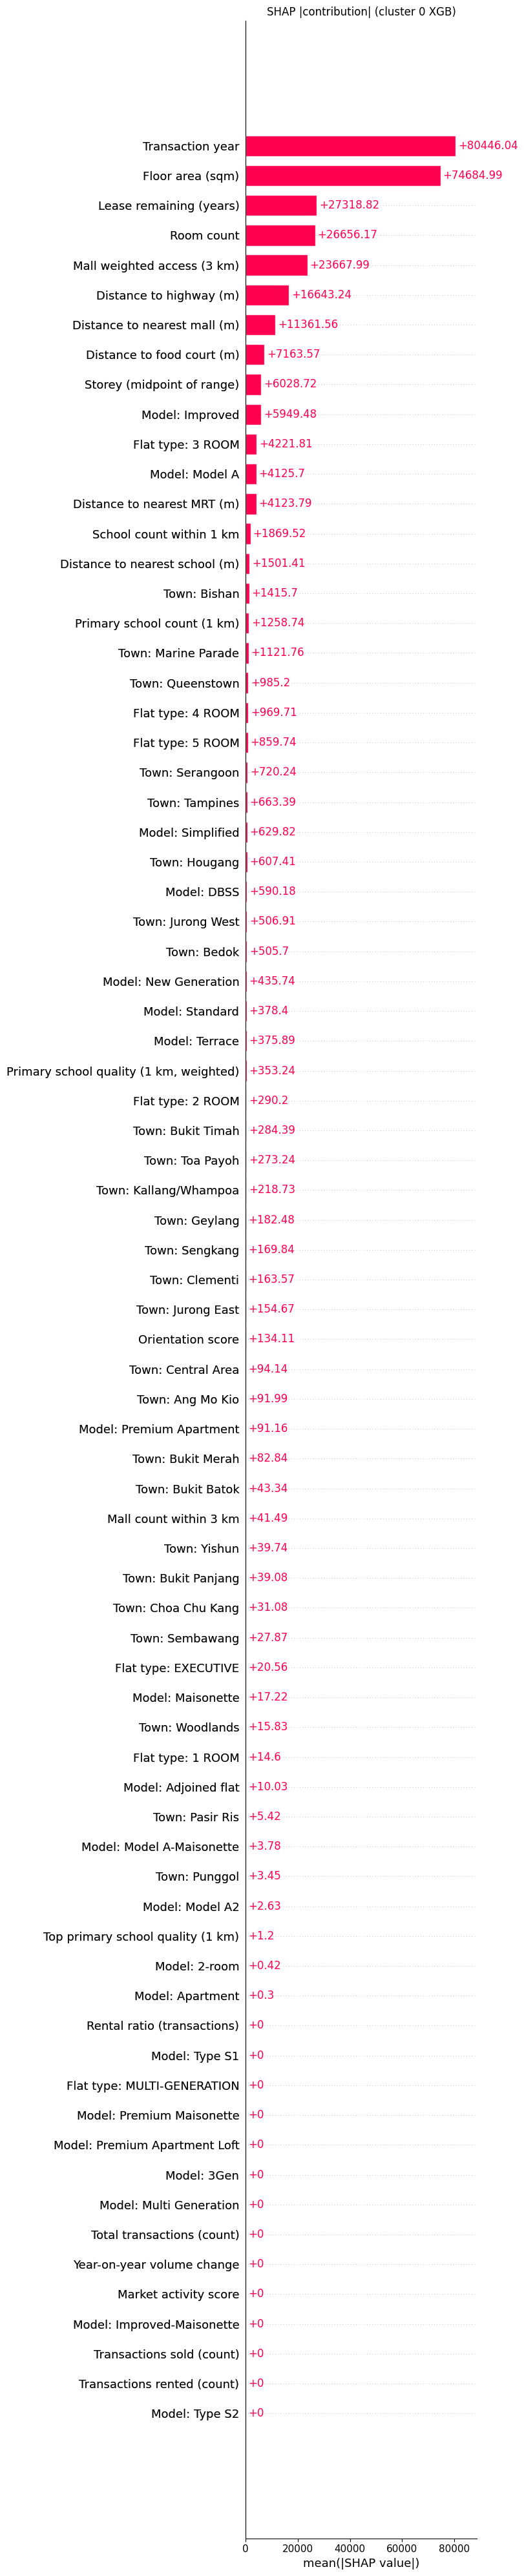

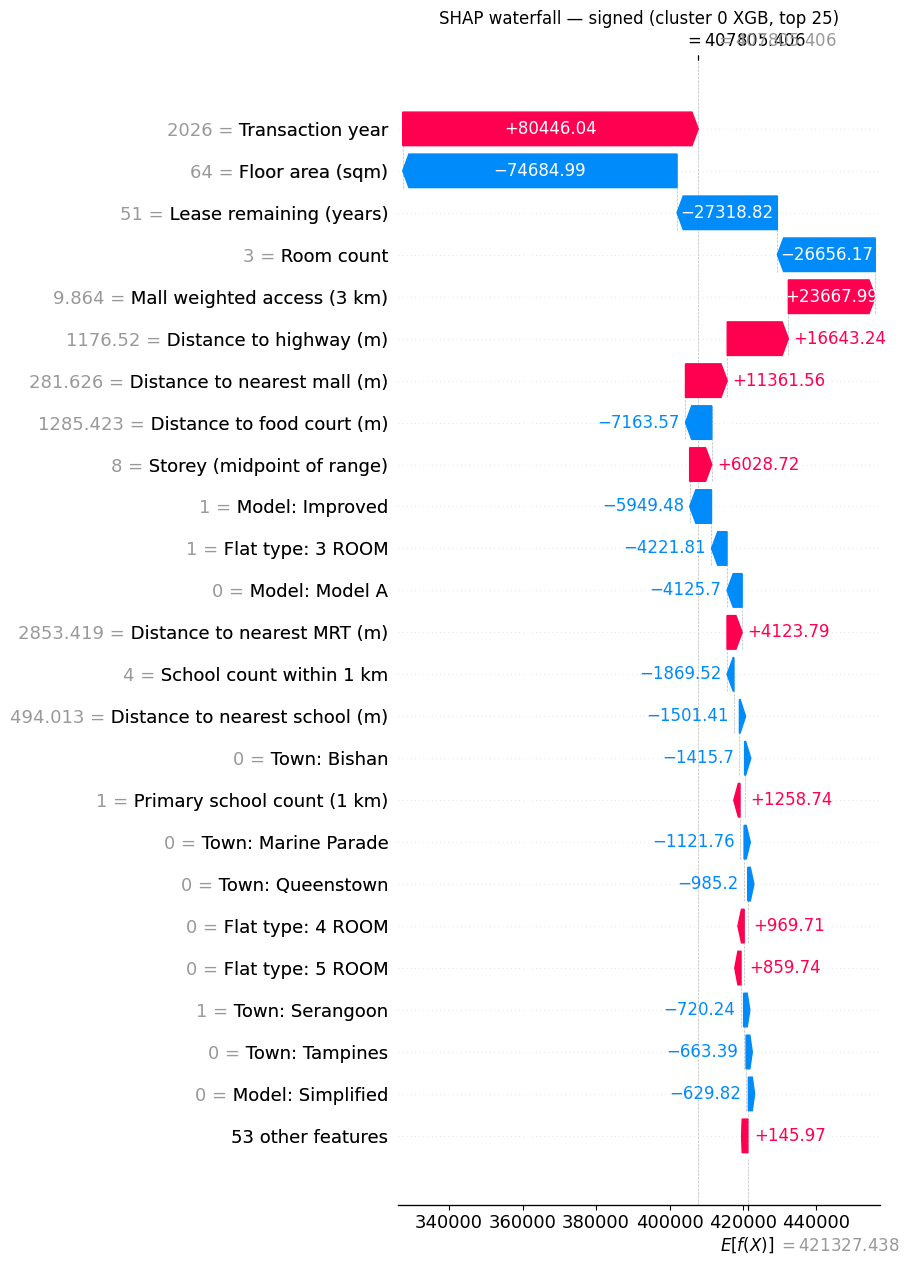

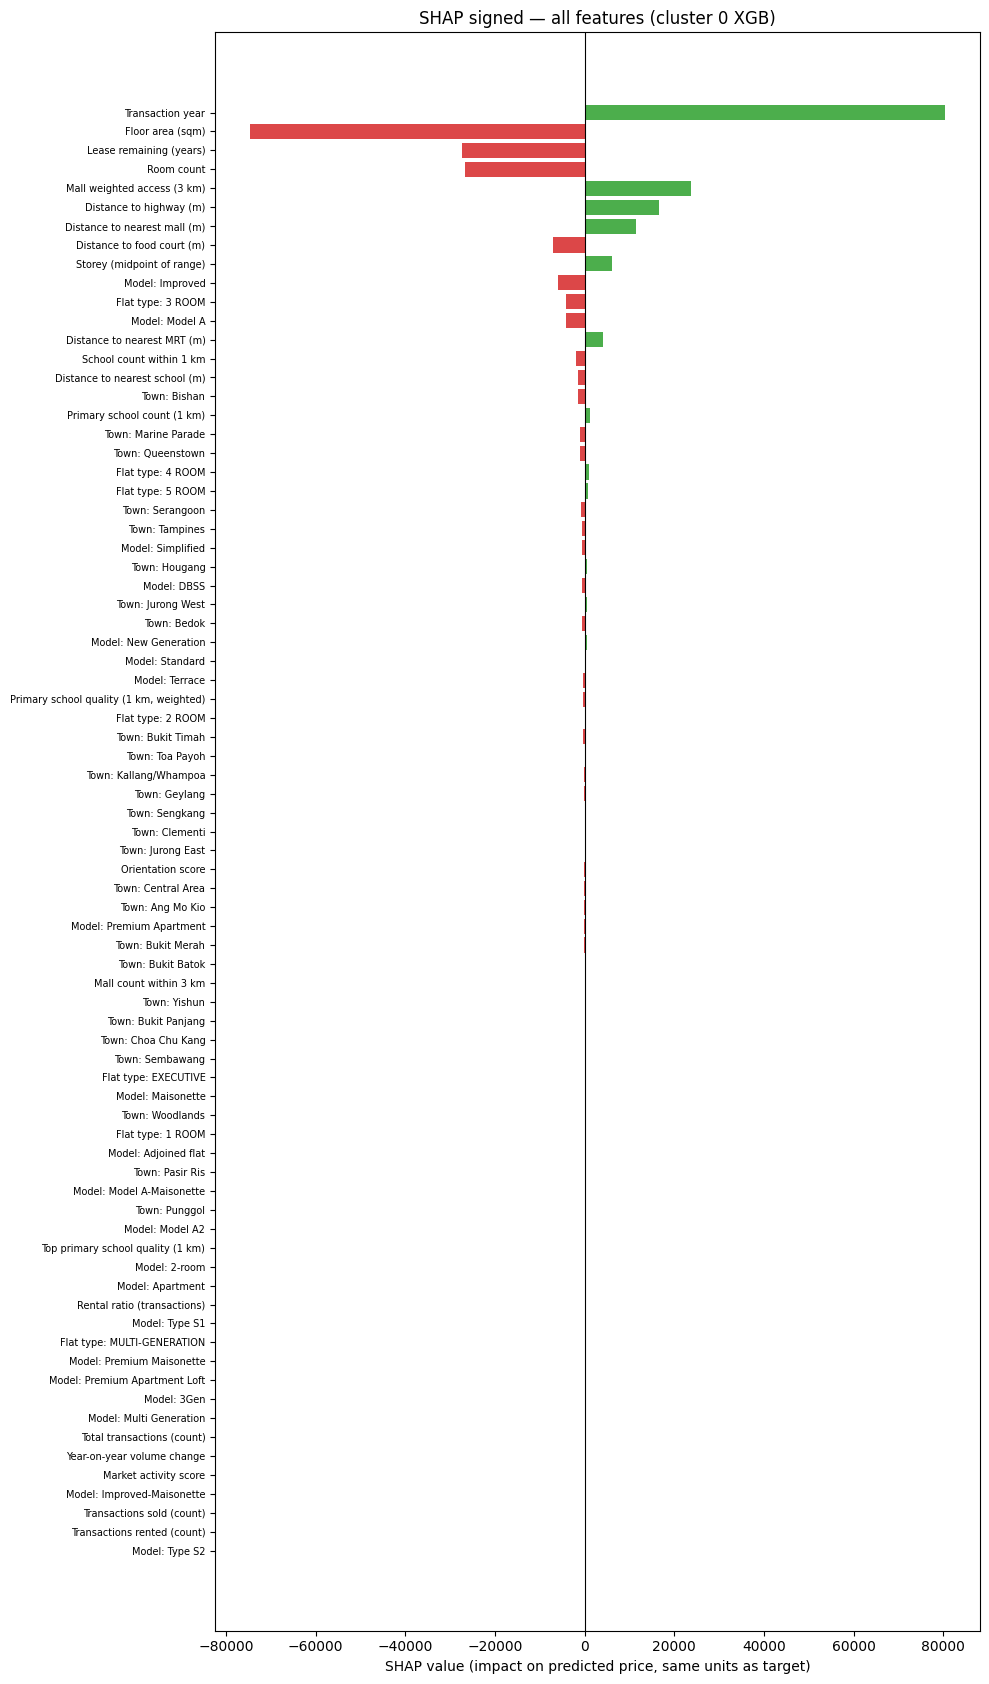

Top features |SHAP|:
  Transaction year                                           80,446
  Floor area (sqm)                                           74,685
  Lease remaining (years)                                    27,319
  Room count                                                 26,656
  Mall weighted access (3 km)                                23,668
  Distance to highway (m)                                    16,643
  Distance to nearest mall (m)                               11,362
  Distance to food court (m)                                  7,164
  Storey (midpoint of range)                                  6,029
  Model: Improved                                             5,949
  Flat type: 3 ROOM                                           4,222
  Model: Model A                                              4,126


In [ ]:
# SHAP bar for this instance (attach feature_names — TreeExplainer on ndarray has none by default)
sv, shap_label, k = shap_for_row(X)
_fname = np.asarray(FEATURE_LABELS)
assert sv.values.shape[-1] == len(_fname), (sv.values.shape[-1], len(_fname))
_sv_data = X if getattr(sv, "data", None) is None else sv.data
sv_named = shap.Explanation(
    values=sv.values,
    base_values=sv.base_values,
    data=_sv_data,
    feature_names=_fname,
)
# Magnitude bar (|SHAP| — all features; bars are non-negative by design)
shap.plots.bar(sv_named, max_display=len(FEATURE_LABELS), show=False)
plt.title(f"SHAP |contribution| ({shap_label})")
plt.tight_layout()
plt.show()

# Signed: waterfall (top contributions; preserves + / −)
_max_w = min(25, len(FEATURE_LABELS))
shap.plots.waterfall(sv_named[0], max_display=_max_w, show=False)
plt.gcf().set_size_inches(9, 0.45 * _max_w + 1.5)
plt.title(f"SHAP waterfall — signed ({shap_label}, top {_max_w})")
plt.tight_layout()
plt.show()

# Signed: all features as horizontal bars (green = up, red = down)
_vals = sv.values[0].astype(float)
_ord = np.argsort(np.abs(_vals))[::-1]
_h = max(6.0, 0.22 * len(_ord))
fig, ax = plt.subplots(figsize=(10, _h))
colors = np.where(_vals[_ord] >= 0.0, "#2ca02c", "#d62728")
ax.barh(np.arange(len(_ord)), _vals[_ord], color=colors, alpha=0.85)
ax.set_yticks(np.arange(len(_ord)))
ax.set_yticklabels([FEATURE_LABELS[i] for i in _ord], fontsize=7)
ax.axvline(0.0, color="black", linewidth=0.8)
ax.set_xlabel("SHAP value (impact on predicted price, same units as target)")
ax.set_title(f"SHAP signed — all features ({shap_label})")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

vals = np.abs(sv.values[0])
order = np.argsort(-vals)[:12]
print("Top features |SHAP|:")
for i in order:
    print(f"  {FEATURE_LABELS[i]:<52} {vals[i]:>12,.0f}")

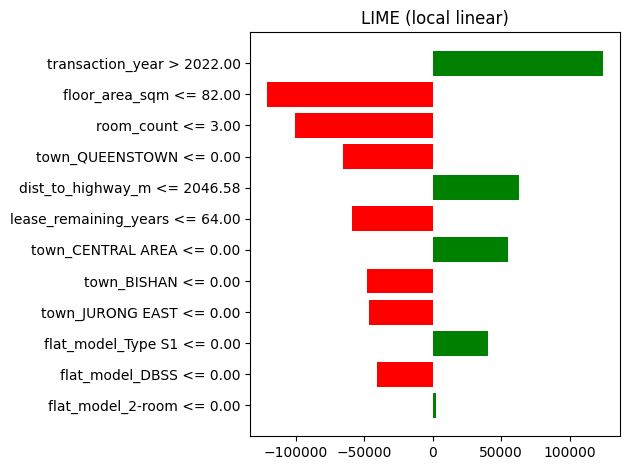

LIME explanation (local linear):
  Transaction year > 2022.00: 124,538
  Floor area (sqm) <= 82.00: -120,901
  Room count <= 3.00: -100,428
  Town: Queenstown <= 0.00: -65,525
  Distance to highway (m) <= 2046.58: 63,380
  Lease remaining (years) <= 64.00: -58,666
  Town: Central Area <= 0.00: 54,738
  Town: Bishan <= 0.00: -48,200
  Town: Jurong East <= 0.00: -46,235
  Model: Type S1 <= 0.00: 40,653
  Model: DBSS <= 0.00: -40,573
  Model: 2-room <= 0.00: 2,305


In [ ]:
# LIME
lime_explainer = lime.lime_tabular.LimeTabularExplainer(
    lime_pack["training_data"],
    feature_names=FEATURE_COLS,
    mode="regression",
    discretize_continuous=True,
)

exp = lime_explainer.explain_instance(
    X[0],
    hybrid_predict,
    num_features=12,
    num_samples=800,
)

# Plot (local linear explanation)
fig_lime = exp.as_pyplot_figure()
plt.title("LIME (local linear)")
plt.tight_layout()
plt.show()

print("LIME explanation (local linear):")
for feat, w in sorted(exp.as_list(), key=lambda x: abs(x[1]), reverse=True)[:12]:
    print(f"  {label_lime_line(feat)}: {w:,.0f}")

In [ ]:
# Surrogate
sp = float(surrogate.predict(X)[0])
print(f"Surrogate tree prediction: {sp:,.0f} SGD (fidelity R² on hybrid is in rules.json metadata)")

# nearest surrogate rule by leaf — simple: show top global surrogate rules
for r in rules_json["surrogate"][:5]:
    conds = [label_rule_text(c) for c in r["conditions"][:4]]
    print(conds, "→", r["then_price"])

Surrogate tree prediction: 393,627 SGD (fidelity R² on hybrid is in rules.json metadata)
['Floor area (sqm) > 84.5', 'Mall count within 3 km <= 12.5', 'Floor area (sqm) <= 111.5', 'Transaction year <= 2020.5'] → 482000.0
['Floor area (sqm) <= 84.5', 'Lease remaining (years) <= 77.5', 'Floor area (sqm) <= 75.5', 'Transaction year <= 2021.5'] → 320000.0
['Floor area (sqm) > 84.5', 'Mall count within 3 km <= 12.5', 'Floor area (sqm) > 111.5', 'Floor area (sqm) <= 139.5'] → 555000.0
['Floor area (sqm) > 84.5', 'Mall count within 3 km <= 12.5', 'Floor area (sqm) <= 111.5', 'Transaction year > 2020.5'] → 528000.0
['Floor area (sqm) > 84.5', 'Mall count within 3 km <= 12.5', 'Floor area (sqm) <= 111.5', 'Transaction year <= 2020.5'] → 402000.0


In [ ]:
# Apriori: build instance bands and count overlap with antecedents
row = pd.Series(X[0], index=FEATURE_COLS)

def band_area(v):
    if v < 70:
        return "area=small(<70sqm)"
    if v < 95:
        return "area=medium(70-95sqm)"
    return "area=large(>95sqm)"


def band_storey(v):
    if v <= 5:
        return "storey=low(1-5)"
    if v <= 12:
        return "storey=mid(6-12)"
    return "storey=high(>12)"


def band_lease(v):
    if v < 55:
        return "lease=short(<55yr)"
    if v < 70:
        return "lease=medium(55-70yr)"
    return "lease=long(>70yr)"


def band_mrt_m(m):
    if m < 400:
        return "mrt=walking(<400m)"
    if m < 800:
        return "mrt=nearby(400-800m)"
    return "mrt=far(>800m)"


inst_tags = {
    band_area(row["floor_area_sqm"]),
    band_storey(row["level_mid"]),
    band_lease(row["lease_remaining_years"]),
    band_mrt_m(row["dist_to_mrt_m"]),
    f"rooms={int(round(row['room_count']))}",
}

scores = []
for r in rules_json["apriori"]:
    ant = set(r["if_conditions"])
    overlap = len(ant & inst_tags)
    if overlap:
        scores.append((overlap, r.get("lift", 0), r))
scores.sort(key=lambda x: (-x[0], -x[1]))
print("Top Apriori rules overlapping instance bands (overlap, lift):")
for ov, lf, r in scores[:8]:
    print(f"  overlap={ov} lift={lf:.2f} | IF {r['if_conditions'][:5]} → {r['then'][:3]}")

Top Apriori rules overlapping instance bands (overlap, lift):
  overlap=3 lift=3.60 | IF ['rooms=3', 'area=small(<70sqm)', 'mrt=far(>800m)', 'lease=medium(55-70yr)'] → ['price=budget(<350k)']
  overlap=3 lift=3.54 | IF ['area=small(<70sqm)', 'storey=low(1-5)', 'mrt=far(>800m)', 'rooms=3'] → ['price=budget(<350k)']
  overlap=3 lift=3.15 | IF ['area=small(<70sqm)', 'mrt=far(>800m)', 'rooms=3'] → ['price=budget(<350k)']
  overlap=3 lift=2.95 | IF ['storey=mid(6-12)', 'mrt=far(>800m)', 'rooms=3'] → ['price=budget(<350k)']
  overlap=2 lift=5.09 | IF ['area=small(<70sqm)', 'mrt=far(>800m)', 'lease=medium(55-70yr)'] → ['price=budget(<350k)', 'rooms=3']
  overlap=2 lift=4.82 | IF ['area=small(<70sqm)', 'mrt=far(>800m)', 'storey=low(1-5)'] → ['price=budget(<350k)', 'rooms=3']
  overlap=2 lift=4.26 | IF ['area=small(<70sqm)', 'mrt=far(>800m)'] → ['price=budget(<350k)', 'rooms=3']
  overlap=2 lift=3.78 | IF ['rooms=3', 'area=small(<70sqm)', 'lease=medium(55-70yr)'] → ['price=budget(<350k)', 'mrt=

In [ ]:
# CBR
q = row[CBR_FEATURES].astype(float).values.reshape(1, -1)
q_n = cbr_scaler.transform(q)
dists, idxs = cbr_tree.query(q_n, k=5)
comp = cbr_df.iloc[idxs[0]].copy()
comp["distance"] = dists[0]
comp["similarity_pct"] = (1 / (1 + dists[0]) * 100).round(1)
print(comp[["address_key", "resale_price", "transaction_year", "distance", "similarity_pct"]].to_string(index=False))

       address_key  resale_price  transaction_year  distance  similarity_pct
    2 JLN BT MERAH      378000.0              2023  0.030782            97.0
    2 JLN BT MERAH      325000.0              2023  0.030782            97.0
 4 BEDOK STH AVE 1      360000.0              2023  0.050633            95.2
 4 BEDOK STH AVE 1      375000.0              2023  0.050633            95.2
329 CLEMENTI AVE 2      408888.0              2023  0.058948            94.4


In [ ]:
# What-if (one feature at a time)
base = price
X0 = X.copy()
variants = ["floor_area_sqm", "lease_remaining_years", "level_mid", "transaction_year"]
rows = []
for col in variants:
    if col not in FEATURE_COLS:
        continue
    ix = FEATURE_COLS.index(col)
    for mult in (0.95, 1.05):
        Z = X0.copy()
        Z[0, ix] = Z[0, ix] * mult
        p = float(hybrid_predict(Z)[0])
        rows.append(
            {
                "feature": feature_label(col),
                "multiplier": mult,
                "new_value": float(Z[0, ix]),
                "predicted_sgd": p,
                "delta_sgd": p - base,
            }
        )

pd.set_option("display.max_columns", None)
_what = pd.DataFrame(rows)
_what.columns = ["Feature", "Multiplier", "New value", "Predicted (SGD)", "Delta (SGD)"]
print(_what.to_string(index=False))

                   Feature  Multiplier  New value  Predicted (SGD)   Delta (SGD)
          Floor area (sqm)        0.95      60.80    401102.733228 -27197.636524
          Floor area (sqm)        1.05      67.20    438504.130315  10203.760564
   Lease remaining (years)        0.95      48.45    411947.530323 -16352.839429
   Lease remaining (years)        1.05      53.55    430547.561979   2247.192227
Storey (midpoint of range)        0.95       7.60    418358.017731  -9942.352021
Storey (midpoint of range)        1.05       8.40    428250.242229    -50.127523
          Transaction year        0.95    1924.70    417966.501614 -10333.868138
          Transaction year        1.05    2127.30    369181.991347 -59118.378405
